# Task 2: Pipeline Proposal & Baseline Experimentation

**Hypothesis:** global geopolitical news helps predict the USD/IDR exchange rate (Bank Indonesia's JISDOR fix).

This notebook is the exploratory analysis and the first experimental results. It reads only what `py -m src.run_task2` produced, so every number here is the pipeline's own.

| § | Content |
|---|---|
| 1 | Task formulation: the target, the class balance, the split |
| 2 | NLP features: what each lexicon sees, how sentiment moves over time |
| 3 | TF-IDF topics: what the SVD axes mean |
| 4 | Do news features relate to the next day's move? (training data only) |
| 5 | Results: price-only baselines vs price + NLP |
| 6 | Findings |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
SPLITS, REP = ROOT / "data" / "splits", ROOT / "reports" / "task2"
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})

parts = {s: pd.read_csv(SPLITS / f"{s}.csv", index_col="date", parse_dates=True) for s in ("train", "val", "test")}
frame = pd.concat(parts.values()).sort_index()
groups = json.loads((SPLITS / "feature_groups.json").read_text())
results = pd.read_csv(REP / "results.csv")
manifest = json.loads((REP / "manifest.json").read_text())
print({g: len(c) for g, c in groups.items()}, manifest["rows"])

{'price': 10, 'market': 4, 'task1_news': 53, 'nlp': 46} {'train': 726, 'val': 235, 'test': 240}


## 1. Task formulation

**Primary target: `y_direction`**, the direction of the next JISDOR fix: UP / FLAT / DOWN, where FLAT means the log return is within ±0.10%. The dead-zone was set in Task 1 so the model is not asked to predict the sign of noise on quiet days.

**Secondary target: `y_return`**, the next-day log return in percent (regression).

**Split:** by date, never shuffled. Train to 31 Aug 2024, validation to 31 Aug 2025, test after. Hyperparameters are chosen on validation; test is scored once.

y_direction,DOWN,FLAT,UP,days
split,,,,
train,29.3,31.8,38.8,726
val,35.3,22.6,42.1,235
test,27.5,32.5,40.0,240


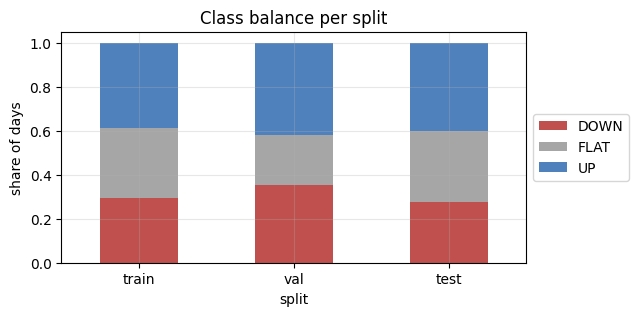

        mean    std    min    max
split                            
test   0.031  0.277 -1.134  0.967
train  0.011  0.333 -1.411  1.891
val    0.026  0.385 -1.231  1.694


In [2]:
balance = frame.groupby("split")["y_direction"].value_counts(normalize=True).unstack().reindex(["train", "val", "test"])
display((balance * 100).round(1).assign(days=frame["split"].value_counts()))
balance[["DOWN", "FLAT", "UP"]].plot.bar(stacked=True, figsize=(6, 3), color=["#c0504d", "#a6a6a6", "#4f81bd"], rot=0,
                                         title="Class balance per split")
plt.ylabel("share of days"); plt.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.show()

print(frame.groupby("split")["y_return"].describe()[["mean", "std", "min", "max"]].round(3))

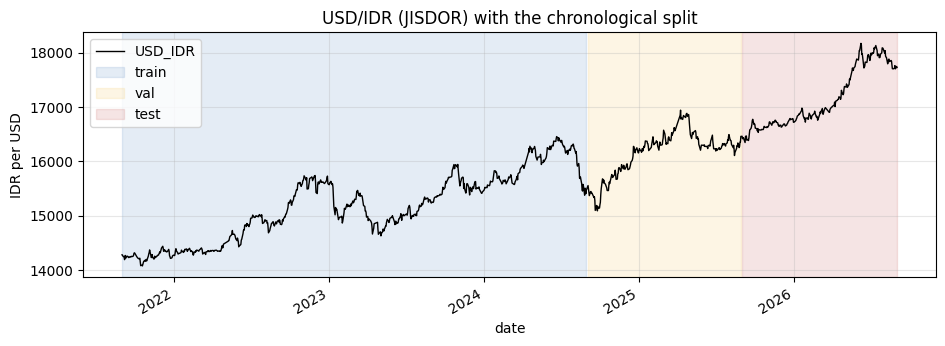

In [3]:
fx = pd.read_parquet(ROOT / "data" / "raw" / "fx_panel.parquet")["USD_IDR"].dropna()
ax = fx.plot(color="black", lw=1, title="USD/IDR (JISDOR) with the chronological split")
for s, c in (("train", "#4f81bd"), ("val", "#f2c14e"), ("test", "#c0504d")):
    idx = parts[s].index
    ax.axvspan(idx.min(), idx.max(), color=c, alpha=0.15, label=s)
ax.set_ylabel("IDR per USD"); ax.legend(); plt.show()

The three periods are different regimes: the rupiah weakened through 2022 to 2024 and again in 2025–2026. A model that learns a level or a trend from training data would fail on test, which is one more reason the target is a *return*, not a level.

## 2. NLP features

Three classical extractors (the brief forbids pre-trained embeddings and transformers), all on **headlines**: GDELT gives no article bodies.

| Extractor | Text | Why |
|---|---|---|
| VADER | Track B (near-raw) | rules read capitals, "!" and negation, which Track A removes |
| Loughran-McDonald | Track A (lemmas) | finance-domain word lists: negative, positive, uncertainty, litigious, constraining |
| TF-IDF → SVD | Track A | learns the vocabulary of *our* corpus, including geopolitical words neither lexicon lists |

Each headline is scored, then averaged per trading-day bucket, weighted by `log1p(dup_count)`.

**First question: how often does each lexicon say anything at all?**

In [4]:
cov = pd.read_csv(REP / "lexicon_coverage.csv").set_index("measure")["value"]
display(cov.to_frame().style.format("{:.3f}"))

,value
measure,
headlines,905713.000
vader_nonzero_share,0.635
vader_negative_share,0.346
vader_positive_share,0.278
lm_any_hit_share,0.461
lm_negative_hit_share,0.313
lm_positive_hit_share,0.096
lm_uncertainty_hit_share,0.058
lm_litigious_hit_share,0.094


In [5]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import sys; sys.path.insert(0, str(ROOT))
from src.config import load_config
from src.nlp_features import load_lm_lexicon, lm_counts

cfg = load_config(ROOT / "config" / "config.yaml")
lex = load_lm_lexicon(ROOT / cfg.dig("task2", "loughran_mcdonald", "path"))
sia = SentimentIntensityAnalyzer()

sample = pd.read_csv(ROOT / "data" / "samples" / "articles_flagged_sample.csv", usecols=["keep", "text_track_a", "text_track_b"])
sample = sample.loc[sample["keep"]].dropna().sample(12, random_state=7)
lm = lm_counts(sample["text_track_a"], {c: lex[c] for c in ("negative", "positive", "uncertainty")})
show = pd.DataFrame({"headline (Track B)": sample["text_track_b"].str[:85].values,
                     "VADER": [sia.polarity_scores(t)["compound"] for t in sample["text_track_b"]],
                     "LM neg": lm["lm_negative"].values, "LM pos": lm["lm_positive"].values,
                     "LM unc": lm["lm_uncertainty"].values})
show

,headline (Track B),VADER,LM neg,LM pos,LM unc
0,Calamos Autocallable Income ETF (CAIE) Delivers Strong First Distribution Following S,0.7964,0,2,0
1,Democrat Midterm Chief Sean Patrick Maloney: We Are the Problem,-0.4019,1,0,0
2,"""Executive order by US administration excludes Pharma sector from immediate tariff im",0.0000,0,1,0
3,"KU nominates seven for Rhodes, Marshall scholarships",0.0000,0,0,0
4,Cryptocurrency can 'spoil young people Modi,0.0000,0,0,0
5,"Dollar stands tall in 2024, propped up by cautious Fed, Trump trade",-0.1027,0,0,1
6,"Keeping China-ROK relations healthy, stable and moving upward",0.5994,0,1,0
7,Program to attract investment back to Taiwan gets three-year extension,0.3612,0,0,0
8,Chamisa's party shows true colours,0.6705,0,0,0
9,Inside the Beltway: Trump enthusiasm is still percolating,0.4404,0,1,0


In [6]:
examples = ["Russia invades Ukraine, markets plunge", "Fed will not cut rates", "Fed will cut rates",
            "Rupiah weakens as uncertainty over tariffs grows", "Ceasefire agreed after peace talks succeed"]
pd.DataFrame({"headline": examples, "VADER compound": [sia.polarity_scores(e)["compound"] for e in examples]})

,headline,VADER compound
0,"Russia invades Ukraine, markets plunge",0.0000
1,Fed will not cut rates,0.2057
2,Fed will cut rates,-0.2732
3,Rupiah weakens as uncertainty over tariffs grows,-0.5719
4,Ceasefire agreed after peace talks succeed,0.8316


The hand-picked examples show each lexicon's blind spot. VADER was built for social media: it reads "not" correctly, but has no entry for *invade* or *plunge*, so a war headline can score as neutral. Loughran-McDonald was built from company 10-K filings: it knows *uncertainty*, *loss* and *crisis*, but not *missile* or *sanction*. Neither was built for geopolitics. That is the reason TF-IDF is in the feature set: it learns its vocabulary from our own headlines.

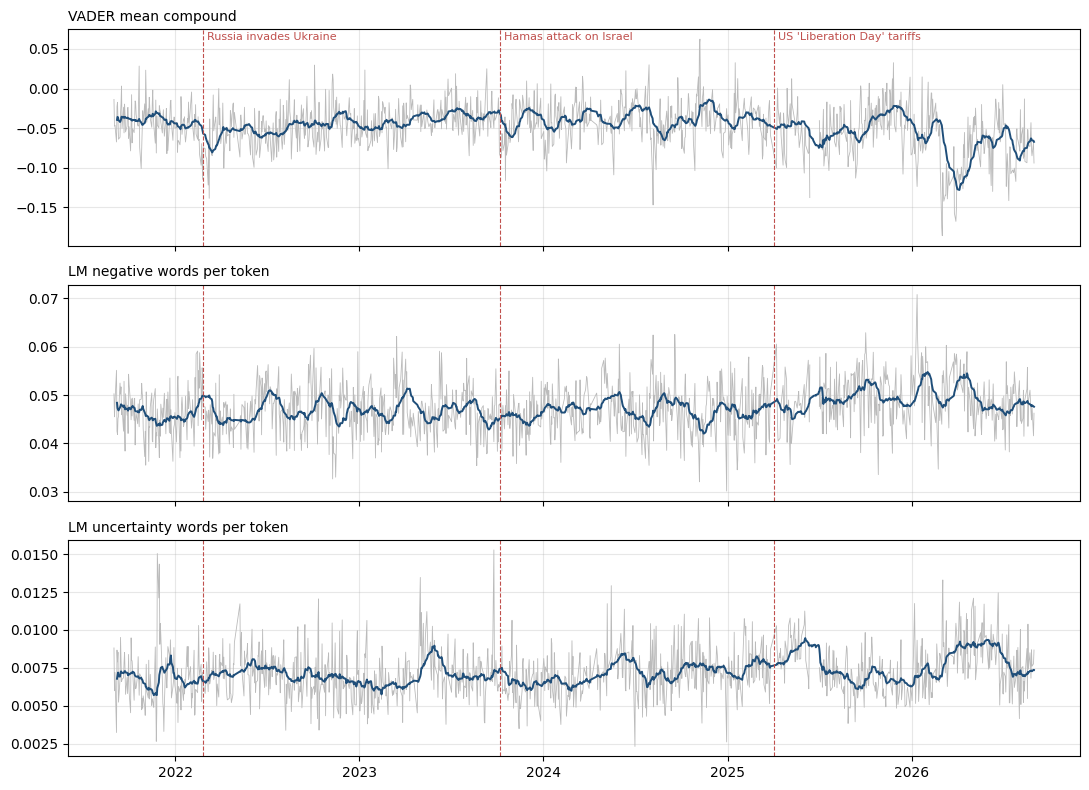

In [7]:
nlp_daily = pd.read_parquet(ROOT / "data" / "processed" / "nlp_daily_features.parquet")
events = {"2022-02-24": "Russia invades Ukraine", "2023-10-07": "Hamas attack on Israel", "2025-04-02": "US 'Liberation Day' tariffs"}
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, col, title in zip(axes, ["nlp_vader_mean", "nlp_lm_negative_rate", "nlp_lm_uncertainty_rate"],
                          ["VADER mean compound", "LM negative words per token", "LM uncertainty words per token"]):
    s = nlp_daily[col]
    ax.plot(s.index, s, color="#bbbbbb", lw=0.6)
    ax.plot(s.index, s.rolling(20, min_periods=5).mean(), color="#1f4e79", lw=1.4)
    ax.set_title(title, loc="left", fontsize=10)
    for d, label in events.items():
        ax.axvline(pd.Timestamp(d), color="#c0504d", ls="--", lw=0.8)
for d, label in events.items():
    axes[0].annotate(label, (pd.Timestamp(d), axes[0].get_ylim()[1]), fontsize=8, color="#c0504d",
                     ha="left", va="top", rotation=0, xytext=(3, -2), textcoords="offset points")
plt.tight_layout(); plt.show()

## 3. TF-IDF topics

The TF-IDF vocabulary, the IDF weights and the SVD axes are fitted on **training-period news only**. Each axis is a direction in word space; the terms that load most on it say what it measures.

In [8]:
print(manifest["tfidf"])
pd.read_csv(REP / "tfidf_svd_top_terms.csv").head(10)

{'fit_before': '2024-08-30', 'n_fit_articles': 539429, 'vocabulary_size': 13532, 'svd_explained_variance': 0.20580966372934956}


,component,explained_variance_ratio,top_positive,top_negative
0,nlp_tfidf_svd_01,0.002210,"<num>, united_states, new, say, biden, <money>, over, not, year, ukraine, china, russia","news prime, automobile construction, financial wire, business wire, calendar feature, ..."
1,nlp_tfidf_svd_02,0.038662,"ukraine, russia, russian, putin, war, oil, sanction, ukrainian, gas, russia ukraine, p...","trump, israel, gaza, hamas, <num>, election, nyse, harris, israeli, strike, inc, donald"
2,nlp_tfidf_svd_03,0.025486,"covid, <num>, covid <num>, omicron, vaccine, climate, jan, jan <num>, cop26, christmas...","israel, trump, ukraine, gaza, hamas, war, russia, nyse, russian, harris, inc, israeli"
3,nlp_tfidf_svd_04,0.015458,"israel, <num>, hamas, gaza, covid, year, omicron, christmas, new year, war, israeli, h...","election, trump, biden, inflation, result, midterm, july, race, abortion, voter, clima..."
4,nlp_tfidf_svd_05,0.013072,"trump, harris, <num>, covid, omicron, biden, convention, kamala, assassination, year, ...","israel, hamas, strike, inflation, united_states, oil, deal, hike, fed, rate, price, debt"
5,nlp_tfidf_svd_06,0.012047,"election, biden, climate, israel, cop26, covid, democrat, hamas, gaza, race, midterm, ...","<num>, strike, year, rate, bank, new year, hike, market, debt, interest, china, trump"
6,nlp_tfidf_svd_07,0.010300,"election, <num>, midterm, minister, china, win, pm, week, party, prime minister, korea...","biden, fed, trump, <money>, oil, united_states, bill, inflation, report, harris, annou..."
7,nlp_tfidf_svd_08,0.009408,"debt, biden, debt ceiling, ceiling, erdogan, turkey, deal, china, mccarthy, talk, clim...","inflation, trump, truss, harris, midterm, <num>, israel, liz, price, liz truss, hamas,..."
8,nlp_tfidf_svd_09,0.008670,"election, <num>, result, midterm, senate, house, quarter, year, win, state, united_sta...","oil, minister, harris, prime, price, prime minister, china, july, week, covid, pm, joh..."
9,nlp_tfidf_svd_10,0.008112,"harris, kamala, kamala harris, dnc, democratic, walz, venezuela, <num>, rate, strike, ...","trump, donald trump, donald, nato, shooting, oil, johnson, assassination, trial, rnc, ..."


## 4. Do news features relate to the next day's move?

Spearman correlation between each (lagged) NLP feature and the next JISDOR return, and its absolute size (a volatility proxy), **on training days only**, so this look at the data cannot influence anything scored on validation or test.

In [9]:
tr = parts["train"]
nlp_cols = groups["nlp"]
corr = pd.DataFrame({
    "corr_with_return": tr[nlp_cols].corrwith(tr["y_return"], method="spearman"),
    "corr_with_abs_return": tr[nlp_cols].corrwith(tr["y_return"].abs(), method="spearman"),
})
corr.reindex(corr["corr_with_abs_return"].abs().sort_values(ascending=False).index).head(15).round(3)

,corr_with_return,corr_with_abs_return
nlp_vader_mean_energy,-0.013,0.133
nlp_tfidf_svd_20,-0.061,0.128
nlp_tfidf_svd_02,0.042,-0.124
nlp_vader_mean_monetary_policy,-0.030,0.119
nlp_tfidf_svd_01,-0.017,-0.110
nlp_tfidf_svd_09,0.028,0.107
nlp_tfidf_svd_04,-0.026,-0.091
nlp_tfidf_svd_05,-0.036,-0.078
nlp_tfidf_svd_16,-0.038,-0.077
nlp_tfidf_svd_17,0.034,-0.073


In [10]:
n = len(tr)
print(f"With n = {n} training days, |rho| above ~{1.96 / np.sqrt(n):.3f} is distinguishable from zero at 5% "
      f"(before correcting for testing {len(nlp_cols)} features at once).")

With n = 726 training days, |rho| above ~0.073 is distinguishable from zero at 5% (before correcting for testing 46 features at once).


## 5. Results

Every learned model is run on several feature sets with the **same** model and tuning grid, so the difference between `price` (the brief's baseline) and `price+nlp` (the combined model) is the news and nothing else. The ablations answer two further questions: does news add anything beyond market controls (`price+market` vs `price+market+nlp`), and do Task 1's volume/theme aggregates carry signal (`price+task1_news`)?

In [11]:
cls = results.query("task == 'cls'").pivot_table(index=["model", "feature_set"], columns="split",
                                                 values=["macro_f1", "accuracy", "directional_hit_rate"])
cls = cls.reindex(columns=["val", "test"], level=1)
cls.round(3)

accuracy        directional_hit_rate        macro_f1       
split                             val   test                  val   test      val   test
model       feature_set                                                                 
arima       price               0.260  0.333                0.457  0.467    0.233  0.208
logreg      all                 0.506  0.350                0.507  0.432    0.446  0.340
            price               0.417  0.338                0.471  0.330    0.403  0.321
            price+market        0.481  0.458                0.526  0.528    0.439  0.458
            price+market+nlp    0.532  0.392                0.538  0.485    0.509  0.388
            price+nlp           0.421  0.350                0.427  0.368    0.398  0.342
            price+task1_news    0.379  0.308                0.398  0.310    0.354  0.304
majority    price               0.421  0.400                0.421  0.400    0.198  0.190
persistence price               0.374  0.383                0.429  0.383    0.347  0.370
xgb         all                 0.519  0.454                0.543  0.532    0.486  0.456
            price               0.396  0.333                0.432  0.325    0.376  0.331
            price+market        0.489  0.438                0.567  0.464    0.441  0.436
            price+market+nlp    0.536  0.425                0.559  0.538    0.493  0.430
            price+nlp           0.409  0.325                0.412  0.336    0.385  0.313
            price+task1_news    0.387  0.367                0.426  0.376    0.343  0.354

In [12]:
gain = pd.read_csv(REP / "news_gain.csv")
gain.pivot_table(index=["task", "model", "without_news", "with_news"], columns="split", values="gain").round(4)

split                                        test     val
task model  without_news with_news                       
cls  logreg price        price+nlp         0.0208 -0.0055
            price+market price+market+nlp -0.0701  0.0691
     xgb    price        price+nlp        -0.0178  0.0085
            price+market price+market+nlp -0.0065  0.0515
reg  ridge  price        price+nlp        -0.0077 -0.0040
            price+market price+market+nlp -0.0046 -0.0019
     xgb    price        price+nlp         0.0126 -0.0043
            price+market price+market+nlp  0.0064 -0.0041

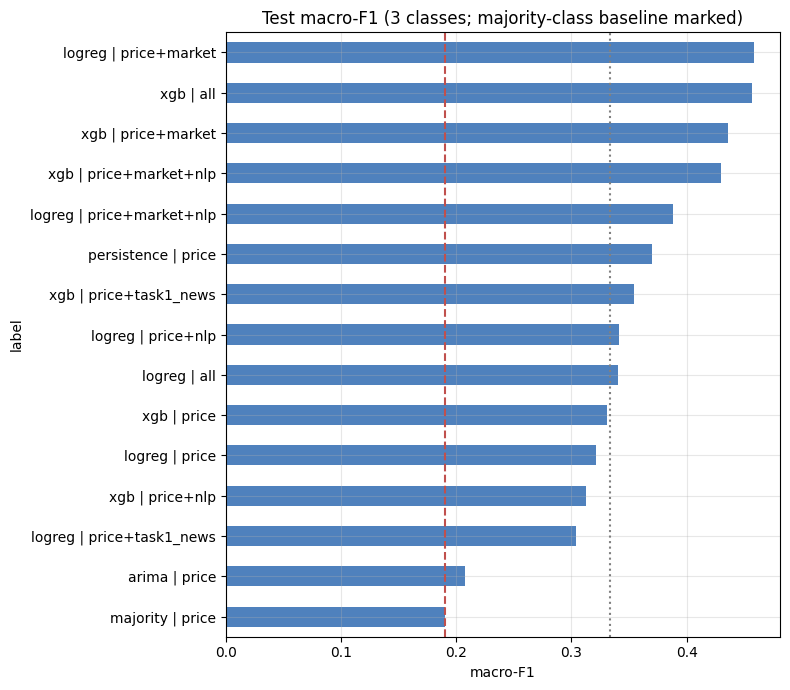

In [13]:
test_cls = results.query("task == 'cls' and split == 'test'").copy()
test_cls["label"] = test_cls["model"] + " | " + test_cls["feature_set"]
test_cls = test_cls.sort_values("macro_f1")
ax = test_cls.plot.barh(x="label", y="macro_f1", legend=False, figsize=(8, 7), color="#4f81bd",
                        title="Test macro-F1 (3 classes; majority-class baseline marked)")
maj = test_cls.loc[test_cls["model"] == "majority", "macro_f1"].iloc[0]
ax.axvline(maj, color="#c0504d", ls="--"); ax.axvline(1 / 3, color="grey", ls=":")
ax.set_xlabel("macro-F1"); plt.tight_layout(); plt.show()

In [14]:
reg = results.query("task == 'reg'").pivot_table(index=["model", "feature_set"], columns="split",
                                                 values=["rmse", "mae", "directional_accuracy", "r2_vs_zero"])
reg.reindex(columns=["val", "test"], level=1).round(4)

directional_accuracy             mae         r2_vs_zero            rmse        
split                                         val    test     val    test        val    test     val    test
model       feature_set                                                                                     
arima       price                          0.5556  0.5319  0.2980  0.2117     0.0193 -0.0218  0.3809  0.2814
persistence price                          0.5427  0.5234  0.3913  0.2974    -0.7465 -0.9515  0.5084  0.3888
ridge       all                            0.6538  0.6213  0.2818  0.1980     0.0966  0.0106  0.3656  0.2769
            price                          0.5470  0.5447  0.2929  0.2096     0.0285 -0.0063  0.3792  0.2792
            price+market                   0.6581  0.6511  0.2673  0.1933     0.1615  0.0978  0.3522  0.2644
            price+market+nlp               0.6667  0.6085  0.2681  0.1992     0.1525  0.0659  0.3541  0.2690
            price+nlp                      0.5470  0.4936  0.2963  0.2184     0.0076 -0.0627  0.3832  0.2869
            price+task1_news               0.5000  0.5362  0.3040  0.2173    -0.0202 -0.0963  0.3885  0.2915
train_mean  price                          0.5214  0.5830  0.2952  0.2067     0.0031  0.0090  0.3841  0.2771
xgb         all                            0.6581  0.6723  0.2693  0.1892     0.1534  0.1182  0.3539  0.2614
            price                          0.5427  0.5404  0.2926  0.2199     0.0340 -0.1119  0.3781  0.2935
            price+market                   0.6453  0.6681  0.2639  0.1985     0.1511  0.0420  0.3544  0.2724
            price+market+nlp               0.6752  0.6681  0.2707  0.1944     0.1314  0.0865  0.3585  0.2660
            price+nlp                      0.5641  0.5660  0.2960  0.2106     0.0117 -0.0183  0.3824  0.2809
            price+task1_news               0.5598  0.5574  0.2921  0.2088     0.0575 -0.0340  0.3734  0.2830
zero        price                          0.0000  0.0000  0.2954  0.2087     0.0000  0.0000  0.3847  0.2784

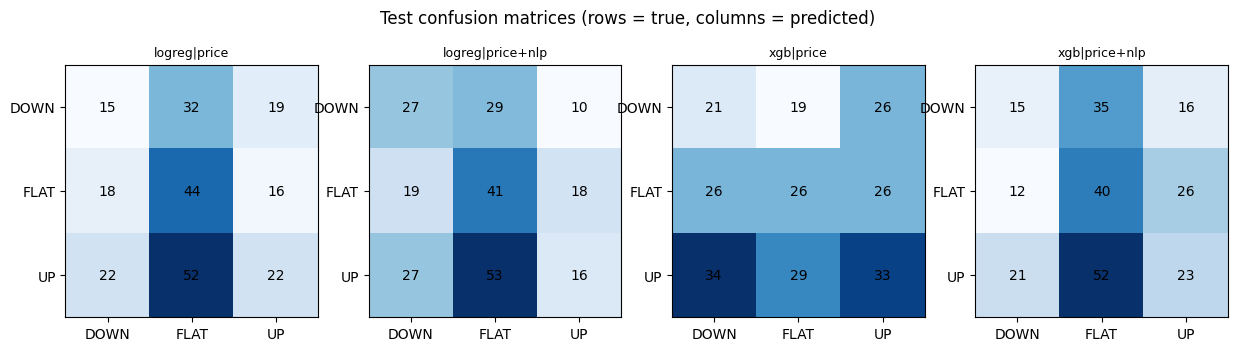

In [15]:
cm = pd.read_csv(REP / "confusion_test.csv")
keys = ["cls|logreg|price", "cls|logreg|price+nlp", "cls|xgb|price", "cls|xgb|price+nlp"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, k in zip(axes, keys):
    m = cm.query("model_key == @k").pivot(index="true", columns="pred", values="count")
    ax.imshow(m.values, cmap="Blues")
    ax.set_xticks(range(3), [c.replace("pred_", "") for c in m.columns]); ax.set_yticks(range(3), [c.replace("true_", "") for c in m.index])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, m.values[i, j], ha="center", va="center")
    ax.set_title(k.replace("cls|", ""), fontsize=9); ax.grid(False)
plt.suptitle("Test confusion matrices (rows = true, columns = predicted)", y=1.03); plt.show()

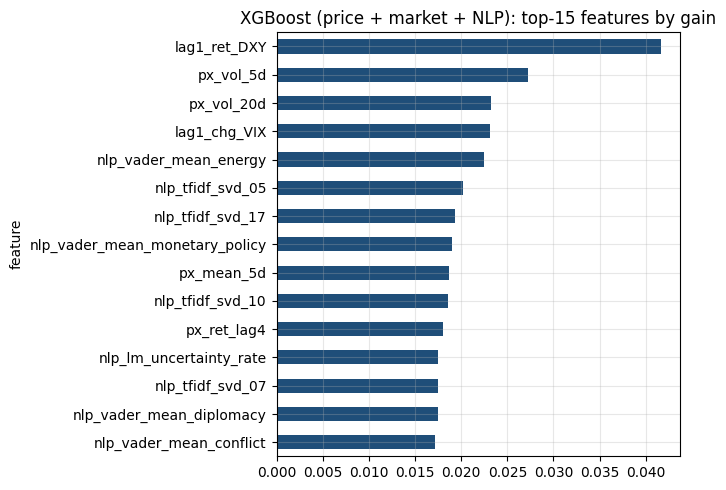

In [16]:
imp = pd.read_csv(REP / "feature_importance.csv")
top = imp.query("model_key == 'cls|xgb|price+market+nlp' and rank <= 15")
top.plot.barh(x="feature", y="importance", legend=False, figsize=(7, 5), color="#1f4e79",
              title="XGBoost (price + market + NLP): top-15 features by gain").invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Findings

Numbers from the run of 27 Sep 2026 (seed 42; a rerun reproduces them). Intervals are 95% block-bootstrap intervals over 10-day blocks (`reports/task2/news_gain.csv`).

**1. Price history alone predicts almost nothing.** On test, macro-F1 is 0.190 for the majority class, 0.208 for ARIMA(2,0,2) (AIC-selected), 0.321 for logistic regression and 0.331 for XGBoost on price features. The simplest rule, "tomorrow moves like today" (persistence), scores 0.370 and beats both learned price models. JISDOR's own past says little about its next move.

**2. The overnight dollar is the strongest predictor.** Adding the lagged market controls (DXY, VIX, Brent) raises test macro-F1 to 0.458 (logistic) and 0.436 (XGBoost), gains of +0.14 [+0.07, +0.21] and +0.11 [+0.06, +0.17]. `lag1_ret_DXY` alone has a Spearman correlation of 0.45 with the next JISDOR return on training days. The mechanism: JISDOR is fixed in the Jakarta afternoon, and the dollar's move during the US session that follows reaches the rupiah at the next fix. (Timing checked: Yahoo stamps DXY bars at 00:00 New York time, so the bar used for fix *t* closes around 05:00 WIB on day *t*, before the fix.)

**3. The NLP features did not add reliable predictive power for direction in this baseline.**
- Price → price + NLP (the brief's baseline vs combined model), test macro-F1: logistic +0.021 [−0.056, +0.125], XGBoost −0.018 [−0.104, +0.077]. Both intervals include zero.
- Price + market → price + market + NLP: on **validation** news appeared to help (logistic +0.069, bootstrap p = 0.04; XGBoost +0.051), but the gain **did not carry over to test** (−0.070 and −0.006). This is the pattern of a feature set that fits one period and not the next, which is why the test set is scored only once.
- Regression tells the same story. One of the 16 news comparisons favours news with an interval above zero (XGBoost, price → price + NLP, test RMSE −0.013). With 16 comparisons, about one such result is expected by chance.
- The best test model overall, XGBoost on all features (macro-F1 0.456), does beat persistence (+0.086 [+0.018, +0.159]), but it owes that mainly to the market controls (finding 2).

**4. News relates more to how much the rupiah moves than to which way.** On training days, 10 of the 46 NLP features correlate with the *absolute* next-day return beyond the 5% threshold (|ρ| > 0.073), against 1 of 46 for the *signed* return, about what chance alone would give (≈ 2.3). The strongest are VADER sentiment of energy and monetary-policy headlines and several TF-IDF topic axes. Geopolitical news looks like a volatility signal more than a direction signal.

**5. Why the lexicons struggle.** VADER scores 36.5% of headlines as exactly neutral, and Loughran-McDonald finds no word at all in 53.9% of them (negative words in 31.3%, uncertainty in 5.8%). Neither lexicon was built for geopolitics: VADER has no entry for *invade*; Loughran-McDonald, built from 10-K filings, has none for *missile* or *sanction*. The TF-IDF axes are interpretable (Ukraine war, COVID, Israel–Gaza, US elections, the debt ceiling), but they describe *which events* happened in the training years, and those events do not recur in the test year.

### What this means for Task 3
- **Target:** add a volatility formulation (|return| or large-move vs normal day), where the news signal is actually visible (finding 4).
- **Features:** a geopolitical-risk dictionary (for example the word lists behind Caldara & Iacoviello's GPR index) in place of general-purpose sentiment; news *surprise* (change against the trailing window) rather than level; Indonesia-specific subsets (headlines mentioning Indonesia, Bank Indonesia or commodity exports).
- **Evaluation:** rolling-origin (walk-forward) evaluation, so a result does not rest on one validation year and one test year.
- **Baseline to beat:** price + market controls (test macro-F1 ≈ 0.44–0.46), not price alone. Any news claim must add to what the overnight dollar already tells us.